In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import joblib

In [14]:
model_data = pd.read_csv('../data/modelling/model_data.csv')
model_data.head()
model_data.shape

(66034, 276)

In [15]:
y = model_data['home_win'].astype(int)

In [16]:
X = model_data.select_dtypes(include='number').drop(columns=['home_win'], errors='ignore')

X.shape, y.shape

((66034, 265), (66034,))

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
log_reg = LogisticRegression(max_iter=500)
log_reg.fit(X_train, y_train)

log_pred = log_reg.predict(X_test)

print("LogReg Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred))

LogReg Accuracy: 0.9981827818581056
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5044
           1       1.00      1.00      1.00      8163

    accuracy                           1.00     13207
   macro avg       1.00      1.00      1.00     13207
weighted avg       1.00      1.00      1.00     13207



c:\Users\HQ6246\.anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

RF Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5044
           1       1.00      1.00      1.00      8163

    accuracy                           1.00     13207
   macro avg       1.00      1.00      1.00     13207
weighted avg       1.00      1.00      1.00     13207



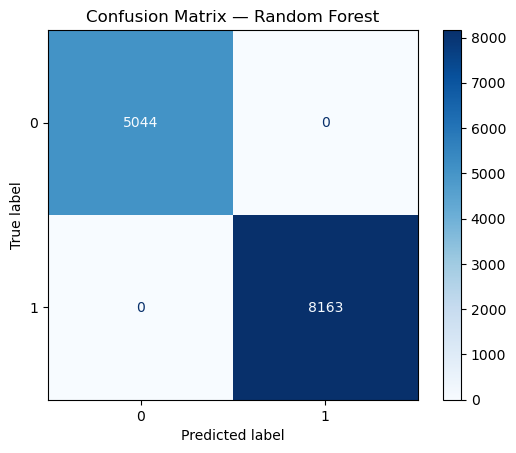

In [20]:
disp = ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    cmap='Blues',
    values_format='d'
)
plt.title("Confusion Matrix — Random Forest")
plt.show()

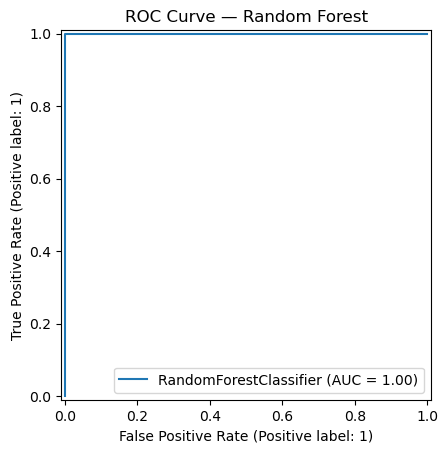

In [21]:
RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curve — Random Forest")
plt.show()

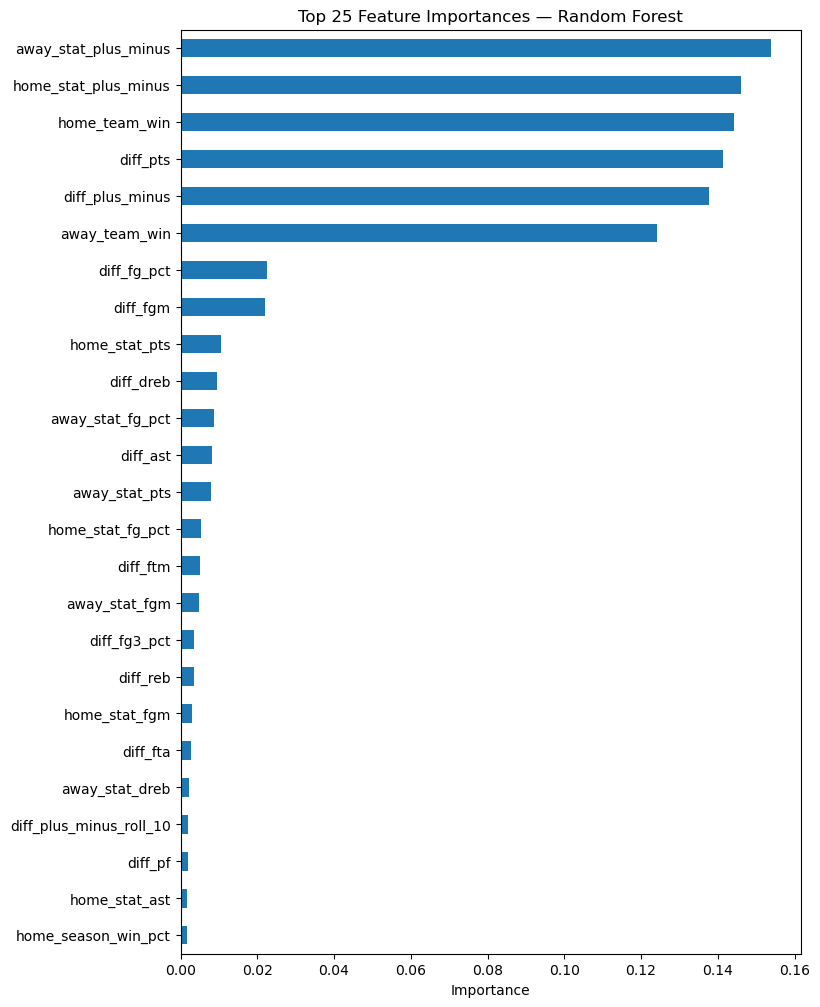

away_stat_plus_minus       0.153865
home_stat_plus_minus       0.146146
home_team_win              0.144273
diff_pts                   0.141444
diff_plus_minus            0.137616
away_team_win              0.124129
diff_fg_pct                0.022426
diff_fgm                   0.021950
home_stat_pts              0.010406
diff_dreb                  0.009491
away_stat_fg_pct           0.008665
diff_ast                   0.008295
away_stat_pts              0.007896
home_stat_fg_pct           0.005187
diff_ftm                   0.004978
away_stat_fgm              0.004719
diff_fg3_pct               0.003559
diff_reb                   0.003376
home_stat_fgm              0.003047
diff_fta                   0.002748
away_stat_dreb             0.002065
diff_plus_minus_roll_10    0.002006
diff_pf                    0.001875
home_stat_ast              0.001762
home_season_win_pct        0.001635
dtype: float64

In [22]:
importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top25 = importances.head(25)

plt.figure(figsize=(8,12))
top25.plot(kind='barh')
plt.title("Top 25 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

top25

In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5044
           1       1.00      1.00      1.00      8163

    accuracy                           1.00     13207
   macro avg       1.00      1.00      1.00     13207
weighted avg       1.00      1.00      1.00     13207



In [24]:
# Save RandomForest
joblib.dump(rf, '../models/random_forest.pkl')

# Save X column order (critical for future prediction)
joblib.dump(list(X.columns), '../models/model_features.pkl')

print("Models saved.")

Models saved.
